In [11]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

In [12]:
df = pd.read_csv('titanic_dataset - titanic_dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Q1. Create a Bar Chart to show the survival rate of passengers from each Embarked port.

#### X-axis: Embarked
#### Y-axis: Average of Survived
#### Add proper title and labels.
#### Identify which port has the highest survival rate.

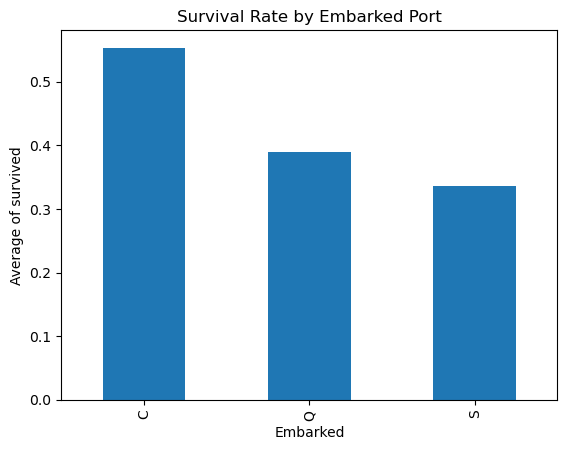

Port with highest survival rate: C
Highest survival rate: 0.5535714285714286


In [13]:
survival_rate = df.groupby('Embarked')['Survived'].mean()
survival_rate.plot(kind='bar')
plt.title('Survival Rate by Embarked Port')
plt.xlabel('Embarked')
plt.ylabel('Average of survived')
plt.show()
print("Port with highest survival rate:", survival_rate.idxmax())
print("Highest survival rate:", survival_rate.max())

***As we can see highest survival rate is C i.e Cherbourg***

### Q2. Create a new column FamilySize using:

#### FamilySize = SibSp + Parch + 1

#### Then create a Count Plot showing the number of passengers for each family-size category.

#### X-axis: FamilySize
#### Y-axis: Number of Passengers
#### Identify the most common family size.

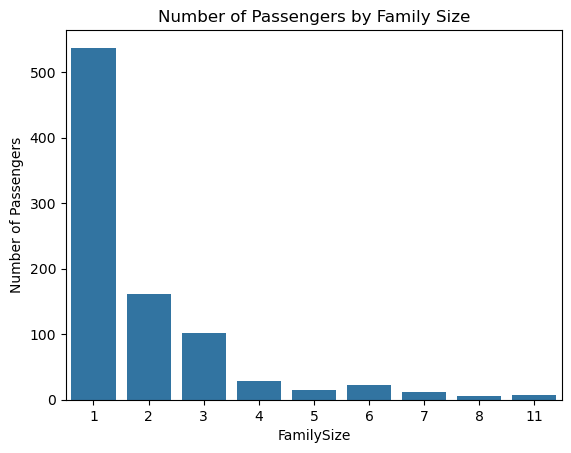

Most common family size: 1


In [14]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
sns.countplot(x='FamilySize', data=df)
plt.title('Number of Passengers by Family Size')
plt.xlabel('FamilySize')
plt.ylabel('Number of Passengers')
plt.show()
print("Most common family size:", df['FamilySize'].mode()[0])

***As we can see,  most passengers were travelling with a family size of 1.***

### Q3. Create a Box Plot to compare Fare across different Pclass, while separating passengers by Sex.

#### X-axis: Pclass
#### Y-axis: Fare
#### Use Sex as hue.
#### Identify which group paid the highest fares.

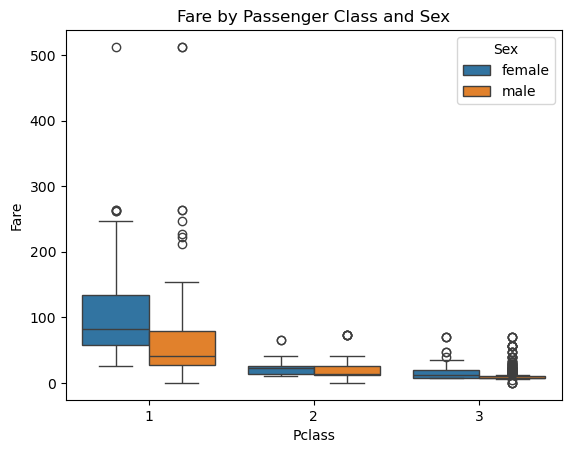

In [15]:
sns.boxplot(x='Pclass',y='Fare',hue='Sex',data=df)
plt.title('Fare by Passenger Class and Sex')
plt.show()

***As we can see , upperclass Female paid the highest Fare***

### Q4. Using the FamilySize column created in Q2, create a Line Plot showing the average survival rate for each family size.

#### X-axis: FamilySize
#### Y-axis: Survival Rate
#### Add markers to the line.
#### Identify the family size with the highest survival rate.

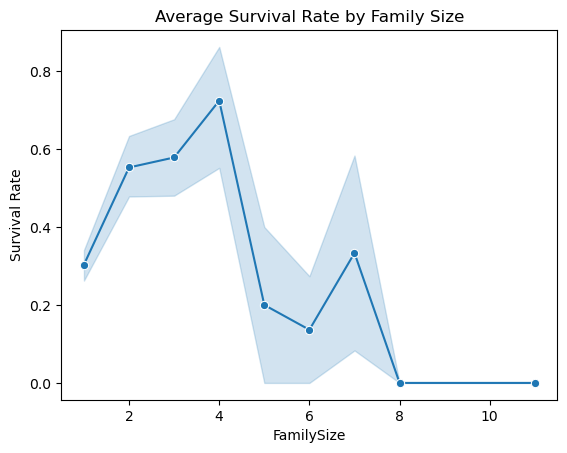

In [37]:
survival_rate=df.groupby('FamilySize')['Survived'].mean()
sns.lineplot(x="FamilySize", y="Survived",data=df,marker='o')
plt.xlabel('FamilySize')
plt.ylabel('Survival Rate')
plt.title('Average Survival Rate by Family Size')
plt.show()


***As we can see , Family size with highest survival rate is 4***

### Q5.Passenger Class & Gender Survival Comparison
#### Create a stacked bar chart showing the number of Survived and Not Survived passengers for each combination of Pclass and Sex.

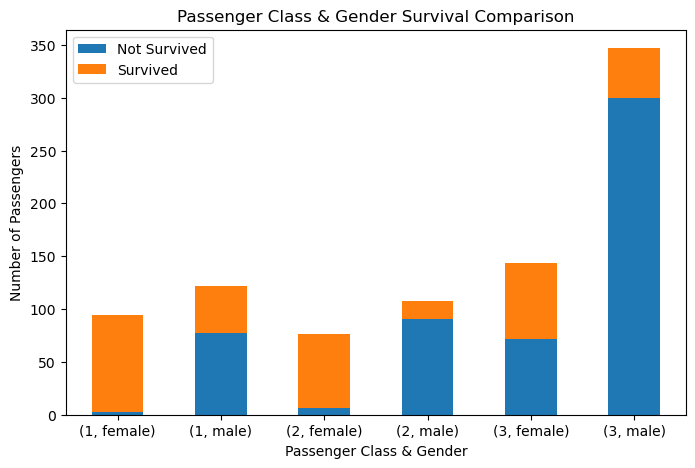

In [10]:
dT = df.groupby(['Pclass', 'Sex', 'Survived']).size().reset_index(name='Count')
pivot_data = dT.pivot_table(index=['Pclass', 'Sex'],columns='Survived',values='Count',fill_value=0)
pivot_data.columns = ['Not Survived', 'Survived']
pivot_data.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.xlabel('Passenger Class & Gender')
plt.ylabel('Number of Passengers')
plt.title('Passenger Class & Gender Survival Comparison')
plt.xticks(rotation=0)
plt.show()